# 実行例6.5 : 正規乱数によるシミュレーションデータ（p.59 図5.8, p.79 図6.5(a)）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using Random
using Distributions
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 正規乱数による3クラスシミュレーションデータの生成（p.59 図5.8）
- 「2次元の正規乱数で生成した3クラスのシミュレーションデータ」の生成は、各クラスを2次元正規分布から独立にサンプリングするだけ。
- 最大識別関数法（ガウス仮定のベイズ識別）は、以下をを最大にするクラスへ割り当てる手法
$$
gc(x)= -\tfrac12(\mathbf{x}-\boldsymbol\mu_c)^\top\Sigma_c^{-1}(\mathbf{x}-\boldsymbol\mu_c) -\tfrac12\ln|\Sigma_c| + \ln P(\omega_c)gc​(x)
$$
- データ自体を正規分布から生成しているなら、この識別関数は生成モデルそのものになる。つまり構成上ベイズ最適な分類器になるので、識別できる傾向をわざわざ仕込む必要はない。
- 調整ノブは実質ひとつだけで、平均の隔たりを広がり（共分散）に対してどれくらい取るか、即ちマハラノビス距離の設定にかかっている。
- 「ほどよく重なった三角配置」を狙うなら、標準偏差 ≈ 1 に対して平均間隔 2〜3 くらいが目安
- シード値で頻出の数字：42は、ダグラス・アダムスのSF小説「銀河ヒッチハイク・ガイド」、から来ていると言われている。

https://qiita.com/ofutonton/items/8cb88b34375bf473e45e

- `MvNormal()` : 平均ベクトルμと共分散行列Σから多変量正規分布を初期化する

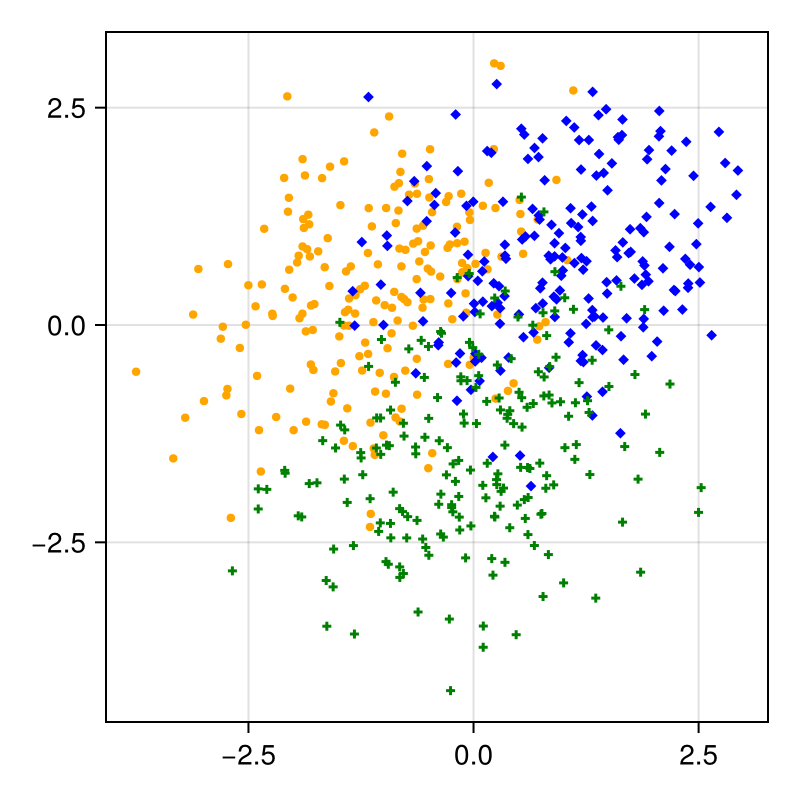

In [2]:
# (1)乱数のシード値固定
Random.seed!(42)

# (2)三角配置になるよう平均を設定
μ = [[-1.0, 0.5],   # クラス1 □
     [ 1.0, 0.8],   # クラス2 ○
     [ 0.0,-1.5]]   # クラス3 ◇

# (2)共分散の設定
Σ = [1.0  0.2; 0.2 1.0]
# 共分散を少しずつ変えると境界が2次曲線になる
# Σ = [[1.0  0.2; 0.2 1.0],
#      [1.2 -0.3;-0.3 1.0],
#      [1.5  0.4; 0.4 1.2]]

# (3)各クラス200個のデータ生成
n = 200
dists = [MvNormal(μ[c], Σ) for c in 1:3]
# dists = [MvNormal(μ[c], Σ[c]) for c in 1:3]     # 2次識別関数の場合
Xc = [rand(dists[c], n) for c in 1:3]   # 各要素は 2×n 行列

# (4)プロット
# マークと色の指定
markers = [:circle, :diamond, :cross]
colors = [:orange, :blue, :green]
# CairoMakieで描画
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1])
for c in 1:3
     scatter!(ax, Xc[c][1,:], Xc[c][2,:],
               marker=markers[c], 
               color=colors[c],
               markersize=6)
end
fig

### 2. 最大識別関数法（p.79 図6.5(a)）
- 「最大識別関数法」という言葉はあまり一般的ではないらしい。
- 多クラス問題の最小2乗誤差基準による線形識別関数<br>
学習データ : $X = (x_1, \cdots ,x_N)^T$<br>
教師データ : $T = (t_1, \cdots, t_N)^T, t_i = \underbrace{(0, \cdots, 1, \cdots, 0)^T}_{K個の要素}$<br>
<br>
2乗誤差を最小にするパラメーター $\hat{W}$ : $\hat{W} = (X^T X)^{-1} X^T X$<br>
識別関数 : $f(x) = \hat{W}^T x = (w_1, \cdots ,w_N)^T x = (f_1(x), \cdots, f_k(x))^T$<br>
識別規則 : $\text{識別クラス}　= arg \, \underset{j}{max} \, f_j(x)$
- `t(c) = Float64.(1:K .== c)` :  `1:K .== c` でc番目だけ`true`の`BitVector`を作り`Float64.()`で変換
- `repeat(..., n)` :  同じ行をn回繰り返す
- `repeat(t(c), 1, n)` : `t(c)`をn列並べたK×n行列
- `hcat(...)` : horizontal concatenation、横方向に結合
- `vcat(...)` : vertical concatenation、縦方向に結合
- `...` : スプラット演算子（配列をバラして個々の引数として展開）。そのまま渡すと`Tc`が1つの配列として扱われるためエラーになる。
- `contour!()`の引数
    - `ax` — 描画先の軸
    - `x1_range` — x軸方向のグリッド座標（range で作った値列）
    - `x2_range` — y軸方向のグリッド座標
    - `class_map` — グリッド各点のクラス番号（Float64の2次元配列、サイズは length(x2_range) × length(x1_range)）
    - `levels=[1.5, 2.5]` — この値の等値線を引く。クラス1→2の境界が1.5、クラス2→3の境界が2.5

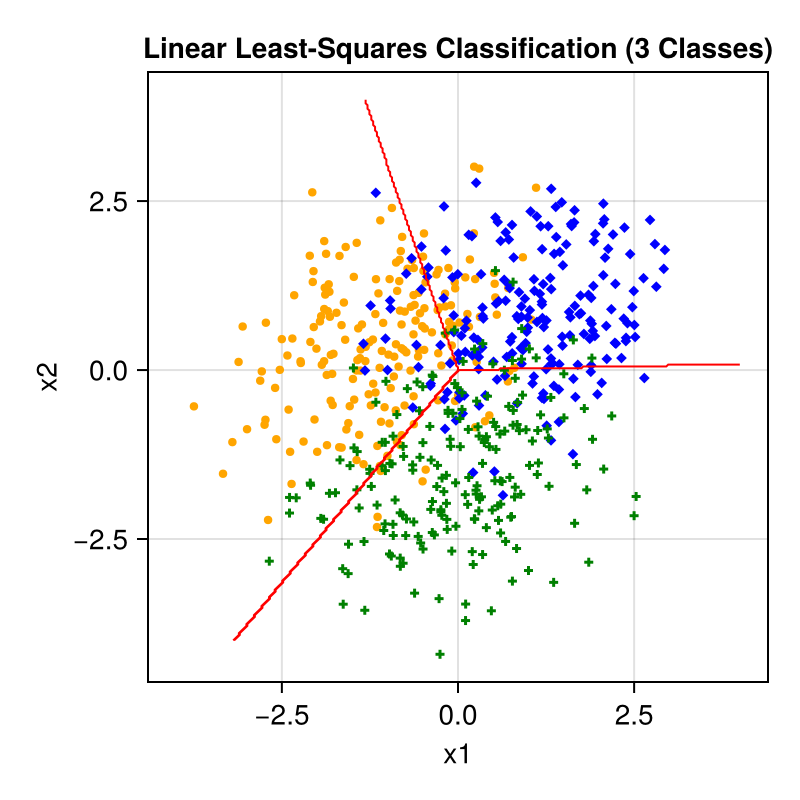

In [3]:
# (1)学習データ
Xt = hcat(Xc...)
X = transpose(Xt)

# (2)教師データ
K = 3
t(c) = Float64.(1:K .== c)   # 例: c=2 → [0.0, 1.0, 0.0]
Tc = [repeat(t(c), 1, n) for c in 1:K]
T = transpose(hcat(Tc...))

# (3)2乗誤差のパラメーター
W_hat = inv(Xt * X) * Xt * T

# (4)識別関数
function discriminant(x::Vector)
    fx = transpose(W_hat) * x
    return fx
end

# (5)グリッドの設定
x1_range = range(-4, 4, length=300)
x2_range = range(-4, 4, length=300)

# (6)各グリッド点のクラス（argmax）を計算
class_map = [Float64(argmax(discriminant([x1, x2])))
             for x2 in x2_range, x1 in x1_range]

# (7)既存のaxに決定境界を追加（クラスが切り替わる等値線）
contour!(ax, x1_range, x2_range, class_map,
         levels=[1.5, 2.5],
         color=:red,
         linewidth=1)
ax.xlabel = "x1"
ax.ylabel = "x2"
ax.title = "Linear Least-Squares Classification (3 Classes)"
save("linclass_least_squares.png", fig)
fig